# TWF – Expertenmodell

## Multivariate logistische Regression mit NumPy

### Features
- Tool wear [min]
- Torque [Nm]

### Begründung
Werkzeugverschleiß und hohes Drehmoment erhöhen die mechanische Belastung des Werkzeugs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Feature Engineering

In [2]:
df["Temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

df["Power_W"] = (
    df["Torque [Nm]"]
    * (2*np.pi*df["Rotational speed [rpm]"]/60)
)

df["Overstrain_index"] = (
    df["Torque [Nm]"]
    * df["Tool wear [min]"]
)


## Hilfsfunktionen

In [3]:
def sigmoid(z):

    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


def add_intercept(X):

    return np.c_[np.ones((X.shape[0],1)), X]


def standardize(X):

    mean = X.mean(axis=0)

    std = X.std(axis=0)

    return (X - mean)/std


def weighted_log_loss(y, p, weights):

    eps = 1e-15

    p = np.clip(p, eps, 1-eps)

    return -np.mean(
        weights * (
            y*np.log(p)
            +
            (1-y)*np.log(1-p)
        )
    )


def fit_logistic_regression(
    X,
    y,
    learning_rate=0.05,
    epochs=20000
):

    Xb = add_intercept(X)

    m, n = Xb.shape

    theta = np.zeros(n)

    positives = np.sum(y == 1)

    negatives = np.sum(y == 0)

    weight_pos = m / (2*positives)

    weight_neg = m / (2*negatives)

    weights = np.where(
        y == 1,
        weight_pos,
        weight_neg
    )

    history = []

    for epoch in range(epochs):

        p = sigmoid(Xb @ theta)

        error = p - y

        gradient = (
            Xb.T @ (weights * error)
        ) / m

        theta -= learning_rate * gradient

        if epoch % 500 == 0:

            loss = weighted_log_loss(
                y,
                p,
                weights
            )

            history.append(loss)

    return theta, history


def predict(X, theta):

    Xb = add_intercept(X)

    p = sigmoid(Xb @ theta)

    return (p >= 0.5).astype(int)


def confusion_matrix_manual(y_true, y_pred):

    tn = np.sum(
        (y_true == 0)
        &
        (y_pred == 0)
    )

    fp = np.sum(
        (y_true == 0)
        &
        (y_pred == 1)
    )

    fn = np.sum(
        (y_true == 1)
        &
        (y_pred == 0)
    )

    tp = np.sum(
        (y_true == 1)
        &
        (y_pred == 1)
    )

    return np.array([
        [tn, fp],
        [fn, tp]
    ])


def f1_score_manual(y_true, y_pred):

    cm = confusion_matrix_manual(
        y_true,
        y_pred
    )

    tn, fp = cm[0]

    fn, tp = cm[1]

    precision = tp / (tp + fp)

    recall = tp / (tp + fn)

    return (
        2 * precision * recall
        /
        (precision + recall)
    )


## TWF-Modell trainieren

In [4]:
features = ['Tool wear [min]', 'Torque [Nm]']

X = df[features].values

y = df["TWF"].values

X = standardize(X)

theta, history = fit_logistic_regression(
    X,
    y
)

y_pred = predict(X, theta)

cm = confusion_matrix_manual(
    y,
    y_pred
)

f1 = f1_score_manual(
    y,
    y_pred
)

print("Theta:", theta)

print("\nConfusion Matrix:")

print(cm)

print("\nF1-Score:", round(f1,4))


Theta: [-8.82101303  6.67478502 -0.12904305]

Confusion Matrix:
[[8851 1103]
 [   0   46]]

F1-Score: 0.077


## Trennlinie plotten

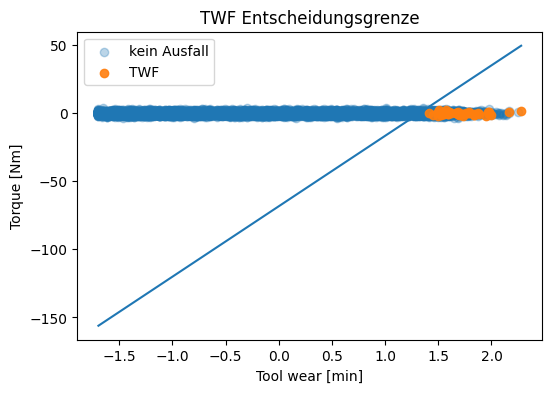

In [5]:
plt.figure(figsize=(6,4))

plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    alpha=0.3,
    label="kein Ausfall"
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    alpha=0.9,
    label="TWF"
)

x_values = np.linspace(
    X[:,0].min(),
    X[:,0].max(),
    200
)

y_values = (
    -(theta[0]
    + theta[1]*x_values)
    / theta[2]
)

plt.plot(
    x_values,
    y_values
)

plt.xlabel(features[0])

plt.ylabel(features[1])

plt.title("TWF Entscheidungsgrenze")

plt.legend()

plt.show()


# Interpretation

## Features
- Tool wear [min]
- Torque [Nm]

## Physikalische Begründung
Werkzeugverschleiß und hohes Drehmoment erhöhen die mechanische Belastung des Werkzeugs.

## Bewertung
- Die gewichtete Kostenfunktion verbessert die Behandlung der Minderheitsklasse.
- Der F1-Score ist besser geeignet als Accuracy.
- Die Trennlinie zeigt die Entscheidungsgrenze der logistischen Regression.
